# 10.1 Modelado Operacional Mensual

Complemento del notebook 10. Este cuaderno no reemplaza el modelado anual principal: lo extiende hacia una capa mensual operativa orientada al trigger, al monitoreo y al dashboard del artefacto.

## Enfoque metodologico

La idea central de este notebook es aprovechar la base mensual para construir un **score operacional de riesgo** sin romper la consistencia metodologica del proyecto.

- La verdad principal de perdida sigue siendo anual.
- La capa mensual se usa para capturar dinamica intra-anual, meses de cosecha y senales tempranas.
- El objetivo supervisado que se asigna a la capa mensual es el target anual repetido por `departamento-anio`.
- La evaluacion importante se hace de dos maneras:
  - a nivel mensual proxy
  - a nivel anualizado, agregando predicciones mensuales por `departamento-anio`

Con esto podemos acercarnos mejor al objetivo final del prototipo, que requiere trigger mensual, alerta operacional y simulacion en dashboard.

## Dependencias

Este notebook usa como minimo:

- `numpy`
- `pandas`
- `scikit-learn`

De forma opcional puede aprovechar:

- `xgboost`
- `matplotlib`
- `seaborn`

No usa `MARS`. Tampoco depende de `lightgbm` o `pygam` para que el flujo base funcione, aunque si mas adelante quieres ampliar esta capa mensual, los podemos reincorporar.

In [17]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)
pd.set_option('display.max_colwidth', 180)

MATPLOTLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
SKLEARN_AVAILABLE = True
XGBOOST_AVAILABLE = True

try:
    import matplotlib.pyplot as plt
except Exception:
    MATPLOTLIB_AVAILABLE = False
    plt = None

try:
    import seaborn as sns
except Exception:
    SEABORN_AVAILABLE = False
    sns = None

try:
    from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
    from sklearn.linear_model import ElasticNet, HuberRegressor, LinearRegression, Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.model_selection import ParameterGrid
    from sklearn.neural_network import MLPRegressor
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
except Exception:
    SKLEARN_AVAILABLE = False

try:
    from xgboost import XGBRegressor
except Exception:
    XGBOOST_AVAILABLE = False


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'BASE_DE_DATOS').exists():
            return candidate
    raise FileNotFoundError('No se encontro una carpeta BASE_DE_DATOS en la ruta actual ni en sus padres.')


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
BASE_DATOS = PROJECT_ROOT / 'BASE_DE_DATOS'
INPUT_MONTHLY = BASE_DATOS / 'FINALES' / 'dataset_operativo_mensual_limpio.csv'
INPUT_ANNUAL = BASE_DATOS / 'FINALES' / 'dataset_modelado_anual_limpio.csv'
OUTPUT_DIR = PROJECT_ROOT / 'MODELOS' / 'resultados_10_1_operacional_mensual'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dependency_report = pd.DataFrame([
    {'dependencia': 'numpy', 'disponible': True},
    {'dependencia': 'pandas', 'disponible': True},
    {'dependencia': 'matplotlib', 'disponible': MATPLOTLIB_AVAILABLE},
    {'dependencia': 'seaborn', 'disponible': SEABORN_AVAILABLE},
    {'dependencia': 'scikit-learn', 'disponible': SKLEARN_AVAILABLE},
    {'dependencia': 'xgboost', 'disponible': XGBOOST_AVAILABLE},
])


In [18]:
if not INPUT_MONTHLY.exists():
    raise FileNotFoundError(f'No existe la base mensual esperada: {INPUT_MONTHLY}')
if not INPUT_ANNUAL.exists():
    raise FileNotFoundError(f'No existe la base anual esperada: {INPUT_ANNUAL}')

print('Rutas validadas correctamente.')
display(dependency_report)
if not SKLEARN_AVAILABLE:
    print('ATENCION: scikit-learn no esta disponible en este entorno. El notebook mostrara preparacion y configuracion, pero no podra correr modelos.')


Rutas validadas correctamente.


,dependencia,disponible
0,numpy,True
1,pandas,True
2,matplotlib,True
3,seaborn,True
4,scikit-learn,True
5,xgboost,True


## Carga de bases finales

Se cargan dos capas:

- base mensual operativa limpia
- base anual de modelado limpia

La segunda se usa aqui solo para recuperar el target anual y hacer la evaluacion anualizada del score mensual.

In [19]:
monthly = pd.read_csv(INPUT_MONTHLY, sep=';').copy()
annual = pd.read_csv(INPUT_ANNUAL, sep=';').copy()

monthly['fecha'] = pd.to_datetime(monthly['fecha'])
monthly = monthly.sort_values(['departamento', 'fecha']).reset_index(drop=True)
monthly['es_risaralda'] = (monthly['departamento'].str.lower() == 'risaralda').astype(int)

annual = annual.sort_values(['departamento', 'anio']).reset_index(drop=True)
annual['es_risaralda'] = (annual['departamento'].str.lower() == 'risaralda').astype(int)

print('Shape base mensual:', monthly.shape)
print('Shape base anual:', annual.shape)
display(monthly[['departamento', 'fecha', 'anio', 'mes']].head(8))
display(annual[['departamento', 'anio', 'perdida_rendimiento_anual_pct', 'evento_perdida_anual']].head(8))


Shape base mensual: (628, 61)
Shape base anual: (36, 81)


,departamento,fecha,anio,mes
0,Cundinamarca,2000-01-01,2000,1
1,Cundinamarca,2000-02-01,2000,2
2,Cundinamarca,2000-03-01,2000,3
3,Cundinamarca,2000-04-01,2000,4
4,Cundinamarca,2000-05-01,2000,5
5,Cundinamarca,2000-06-01,2000,6
6,Cundinamarca,2000-07-01,2000,7
7,Cundinamarca,2000-08-01,2000,8


,departamento,anio,perdida_rendimiento_anual_pct,evento_perdida_anual
0,Cundinamarca,2007,-15.245048,1
1,Cundinamarca,2008,-11.479062,0
2,Cundinamarca,2009,-7.713077,0
3,Cundinamarca,2010,-9.120406,0
4,Cundinamarca,2011,-5.456866,0
5,Cundinamarca,2012,-10.482027,0
6,Cundinamarca,2013,-25.345584,1
7,Cundinamarca,2014,-19.247836,1


## Definicion del objetivo operacional

La base mensual no tiene una perdida mensual observada con el mismo nivel de validez que la anual. Por eso:

- no se inventa un target mensual nuevo
- se toma el target anual observado
- se replica por `departamento-anio`
- luego se entrena un score mensual que, al agregarse, debe aproximar la perdida anual

Esto convierte al notebook 10.1 en una capa puente entre el modelado anual y el trigger mensual del artefacto.

In [20]:
TARGET = 'perdida_rendimiento_anual_pct'
EVENT_THRESHOLD = -15.0
TRAIN_END_YEAR = 2018
TEST_START_YEAR = 2019
CV_MIN_TRAIN_YEARS = 6
CV_VALID_WINDOW = 2

annual_target_cols = [
    'departamento',
    'anio',
    'perdida_rendimiento_anual_pct',
    'evento_perdida_anual',
    'precio_ico_usd_ton',
]

monthly = monthly.merge(
    annual[annual_target_cols],
    on=['departamento', 'anio'],
    how='left',
    suffixes=('', '_annual_ref')
)

monthly['en_ventana_supervisada'] = monthly['anio'].between(2007, 2024)
monthly['en_holdout_operacional'] = monthly['anio'].between(TEST_START_YEAR, 2024)
monthly['sample_tipo_mes'] = np.where(monthly['es_mes_cosecha'] == 1, 'cosecha', 'resto')

display(
    pd.DataFrame([
        {'dataset': 'monthly_total', 'filas': len(monthly), 'anio_min': int(monthly['anio'].min()), 'anio_max': int(monthly['anio'].max())},
        {'dataset': 'monthly_supervisada', 'filas': int(monthly['en_ventana_supervisada'].sum()), 'anio_min': 2007, 'anio_max': 2024},
        {'dataset': 'monthly_cosecha_supervisada', 'filas': int(((monthly['en_ventana_supervisada']) & (monthly['es_mes_cosecha'] == 1)).sum()), 'anio_min': 2007, 'anio_max': 2024},
    ])
)


,dataset,filas,anio_min,anio_max
0,monthly_total,628,2000,2026
1,monthly_supervisada,432,2007,2024
2,monthly_cosecha_supervisada,216,2007,2024


## Helpers

Las funciones siguientes organizan:

- validacion temporal
- metricas de regresion
- metricas de eventos a partir del score anualizado
- agregacion mensual → anual
- escritura de salidas

In [21]:
run_log = []


def log(message: str):
    print(message)
    run_log.append(message)


def flatten_pred(pred):
    pred = np.asarray(pred)
    if pred.ndim > 1:
        pred = pred.reshape(-1)
    return pred.astype(float)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    if len(y_true) > 1 and np.std(y_true) > 0:
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan
    return {'mae': mae, 'rmse': rmse, 'r2': float(r2)}


def event_metrics_from_regression(y_true, y_pred, threshold=-15.0):
    actual = np.asarray(y_true) <= threshold
    pred = np.asarray(y_pred) <= threshold
    tp = int(np.sum(actual & pred))
    fp = int(np.sum(~actual & pred))
    fn = int(np.sum(actual & ~pred))
    tn = int(np.sum(~actual & ~pred))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    return {
        'event_precision': float(precision),
        'event_recall': float(recall),
        'event_f1': float(f1),
        'event_accuracy': float(accuracy),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    }


def make_expanding_year_folds(train_df, year_col='anio', min_train_years=6, valid_window=2):
    years = sorted(train_df[year_col].unique().tolist())
    folds = []
    for end_idx in range(min_train_years, len(years), valid_window):
        train_years = years[:end_idx]
        valid_years = years[end_idx:end_idx + valid_window]
        if not valid_years:
            continue
        train_idx = train_df.index[train_df[year_col].isin(train_years)].tolist()
        valid_idx = train_df.index[train_df[year_col].isin(valid_years)].tolist()
        folds.append({
            'train_years': train_years,
            'valid_years': valid_years,
            'train_idx': train_idx,
            'valid_idx': valid_idx,
            'label': f"train_{train_years[0]}_{train_years[-1]}__valid_{valid_years[0]}_{valid_years[-1]}"
        })
    return folds


def aggregate_monthly_to_annual(df_pred, sample_name):
    work = df_pred.copy()
    if sample_name == 'solo_cosecha':
        grouped = work.groupby(['departamento', 'anio'], as_index=False).agg(
            y_real=('y_real', 'first'),
            y_pred_monthly_mean=('y_pred', 'mean'),
            y_pred_monthly_max=('y_pred', 'max'),
            n_meses=('y_pred', 'size')
        )
        grouped['y_pred_annualized'] = grouped['y_pred_monthly_mean']
    else:
        grouped = work.groupby(['departamento', 'anio'], as_index=False).agg(
            y_real=('y_real', 'first'),
            y_pred_monthly_mean=('y_pred', 'mean'),
            y_pred_monthly_max=('y_pred', 'max'),
            y_pred_monthly_min=('y_pred', 'min'),
            n_meses=('y_pred', 'size')
        )
        grouped['y_pred_annualized'] = grouped['y_pred_monthly_mean']
    return grouped


def safe_write_text(path: Path, content: str):
    try:
        path.write_text(content, encoding='utf-8')
        return True
    except Exception as exc:
        print(f'No fue posible escribir {path.name}: {exc}')
        return False


## Feature engineering mensual

Se crean senales operativas utiles para un trigger mensual:

- `sin` y `cos` del mes
- rezagos mensuales por departamento
- promedios moviles cortos

Estas variables permiten capturar inercia y estacionalidad sin salirse del flujo mensual del dashboard.

In [22]:
monthly['mes_sin'] = np.sin(2 * np.pi * monthly['mes'] / 12.0)
monthly['mes_cos'] = np.cos(2 * np.pi * monthly['mes'] / 12.0)

lag_vars = [
    'precipitation',
    'temp_aire_C',
    'def',
    'NDVI_anomalia_pct',
    'Gpp_anomalia_pct',
    'indice_perdida',
]

for var in lag_vars:
    if var not in monthly.columns:
        continue
    monthly[f'{var}_lag1'] = monthly.groupby('departamento')[var].shift(1)
    monthly[f'{var}_lag2'] = monthly.groupby('departamento')[var].shift(2)
    monthly[f'{var}_roll3'] = (
        monthly.groupby('departamento')[var]
        .rolling(window=3, min_periods=2)
        .mean()
        .reset_index(level=0, drop=True)
    )

display(
    monthly[
        [
            'departamento', 'fecha', 'mes', 'mes_sin', 'mes_cos',
            'precipitation', 'precipitation_lag1', 'precipitation_roll3'
        ]
    ].head(10)
)


,departamento,fecha,mes,mes_sin,mes_cos,precipitation,precipitation_lag1,precipitation_roll3
0,Cundinamarca,2000-01-01,1,5.000000e-01,8.660254e-01,58.122070,NaN,NaN
1,Cundinamarca,2000-02-01,2,8.660254e-01,5.000000e-01,102.480240,58.122070,80.301155
2,Cundinamarca,2000-03-01,3,1.000000e+00,6.123234e-17,126.669177,102.480240,95.757162
3,Cundinamarca,2000-04-01,4,8.660254e-01,-5.000000e-01,146.966135,126.669177,125.371851
4,Cundinamarca,2000-05-01,5,5.000000e-01,-8.660254e-01,238.109657,146.966135,170.581656
5,Cundinamarca,2000-06-01,6,1.224647e-16,-1.000000e+00,157.276865,238.109657,180.784219
6,Cundinamarca,2000-07-01,7,-5.000000e-01,-8.660254e-01,140.563312,157.276865,178.649945
7,Cundinamarca,2000-08-01,8,-8.660254e-01,-5.000000e-01,133.568160,140.563312,143.802779
8,Cundinamarca,2000-09-01,9,-1.000000e+00,-1.836970e-16,173.115534,133.568160,149.082335
9,Cundinamarca,2000-10-01,10,-8.660254e-01,5.000000e-01,182.996604,173.115534,163.226766


## Definicion de muestras y conjuntos de variables

Se trabajan dos muestras complementarias:

- `mensual_completo`: todos los meses de 2007–2024
- `solo_cosecha`: solo meses de cosecha

La primera ayuda al monitoreo completo del ano. La segunda se alinea mejor con la logica de activacion del seguro.

In [23]:
base_features = [
    'es_risaralda',
    'mes',
    'mes_sin',
    'mes_cos',
    'es_mes_cosecha',
    'precio_ico_usd_ton',
    'precipitation',
    'temp_aire_C',
    'def',
    'GDD_cafe',
    'NDVI',
    'EVI',
    'Gpp',
    'NDVI_anomalia_pct',
    'EVI_anomalia_pct',
    'Gpp_anomalia_pct',
    'indice_perdida',
]

lag_feature_candidates = [
    'precipitation_lag1', 'precipitation_lag2', 'precipitation_roll3',
    'temp_aire_C_lag1', 'temp_aire_C_lag2', 'temp_aire_C_roll3',
    'def_lag1', 'def_lag2', 'def_roll3',
    'NDVI_anomalia_pct_lag1', 'NDVI_anomalia_pct_lag2', 'NDVI_anomalia_pct_roll3',
    'Gpp_anomalia_pct_lag1', 'Gpp_anomalia_pct_lag2', 'Gpp_anomalia_pct_roll3',
    'indice_perdida_lag1', 'indice_perdida_lag2', 'indice_perdida_roll3',
]

available_lag_features = [c for c in lag_feature_candidates if c in monthly.columns]

feature_sets = {
    'mensual_core': [c for c in base_features if c in monthly.columns],
    'mensual_core_lags': [c for c in base_features if c in monthly.columns] + available_lag_features,
    'mensual_cosecha_focus': [c for c in [
        'es_risaralda', 'mes', 'mes_sin', 'mes_cos', 'precio_ico_usd_ton',
        'precipitation', 'temp_aire_C', 'def', 'NDVI', 'Gpp',
        'NDVI_anomalia_pct', 'Gpp_anomalia_pct', 'indice_perdida'
    ] if c in monthly.columns],
}

feature_sets_table = pd.DataFrame([
    {'feature_set': name, 'n_variables': len(cols), 'variables': ', '.join(cols)}
    for name, cols in feature_sets.items()
])
display(feature_sets_table)

sample_configs = [
    {
        'sample_name': 'mensual_completo',
        'df': monthly.loc[monthly['en_ventana_supervisada']].copy().reset_index(drop=True),
    },
    {
        'sample_name': 'solo_cosecha',
        'df': monthly.loc[(monthly['en_ventana_supervisada']) & (monthly['es_mes_cosecha'] == 1)].copy().reset_index(drop=True),
    },
]

sample_summary = []
for cfg in sample_configs:
    sdf = cfg['df'].copy()
    sdf = sdf.dropna(subset=[TARGET])
    sample_summary.append({
        'sample_name': cfg['sample_name'],
        'filas': len(sdf),
        'anios_train': '2007-2018',
        'anios_test': '2019-2024',
        'deptos': sdf['departamento'].nunique(),
    })
display(pd.DataFrame(sample_summary))


,feature_set,n_variables,variables
0,mensual_core,17,"es_risaralda, mes, mes_sin, mes_cos, es_mes_cosecha, precio_ico_usd_ton, precipitation, temp_aire_C, def, GDD_cafe, NDVI, EVI, Gpp, NDVI_anomalia_pct, EVI_anomalia_pct, Gpp_ano..."
1,mensual_core_lags,35,"es_risaralda, mes, mes_sin, mes_cos, es_mes_cosecha, precio_ico_usd_ton, precipitation, temp_aire_C, def, GDD_cafe, NDVI, EVI, Gpp, NDVI_anomalia_pct, EVI_anomalia_pct, Gpp_ano..."
2,mensual_cosecha_focus,13,"es_risaralda, mes, mes_sin, mes_cos, precio_ico_usd_ton, precipitation, temp_aire_C, def, NDVI, Gpp, NDVI_anomalia_pct, Gpp_anomalia_pct, indice_perdida"


,sample_name,filas,anios_train,anios_test,deptos
0,mensual_completo,432,2007-2018,2019-2024,2
1,solo_cosecha,216,2007-2018,2019-2024,2


## Smoke test del flujo mensual

Antes de correr el comparativo completo, se prueba el pipeline con una regresion lineal simple en la muestra mensual completa.

In [24]:
smoke_test_result = None

if SKLEARN_AVAILABLE:
    smoke_df = sample_configs[0]['df'].copy()
    smoke_df = smoke_df.dropna(subset=feature_sets['mensual_core'] + [TARGET]).reset_index(drop=True)
    smoke_train = smoke_df.loc[smoke_df['anio'] <= TRAIN_END_YEAR].copy()
    smoke_test = smoke_df.loc[smoke_df['anio'] >= TEST_START_YEAR].copy()

    smoke_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    smoke_model.fit(smoke_train[feature_sets['mensual_core']], smoke_train[TARGET])
    smoke_pred = flatten_pred(smoke_model.predict(smoke_test[feature_sets['mensual_core']]))
    smoke_metrics = regression_metrics(smoke_test[TARGET], smoke_pred)
    smoke_test_result = pd.DataFrame([smoke_metrics])
    display(smoke_test_result)
    log('Smoke test operacional mensual completado correctamente con Regresion Lineal.')
else:
    print('Se omite el smoke test porque scikit-learn no esta disponible en este entorno.')


,mae,rmse,r2
0,16.269195,20.292483,-0.882087


Smoke test operacional mensual completado correctamente con Regresion Lineal.


## Registro de modelos operacionales

Se priorizan modelos razonables para un score mensual:

- lineales y robustos
- regularizados
- arboles
- boosting
- red neuronal compacta
- `XGBoost` opcional

In [25]:
model_specs = []

if SKLEARN_AVAILABLE:
    model_specs.extend([
        {'model_name': 'LinearRegression', 'family': 'lineal', 'param_grid': [{}]},
        {'model_name': 'HuberRegressor', 'family': 'lineal_robusto', 'param_grid': list(ParameterGrid({'epsilon': [1.15, 1.35], 'alpha': [0.0001, 0.001]}))},
        {'model_name': 'Ridge', 'family': 'regularizado', 'param_grid': list(ParameterGrid({'alpha': [0.1, 1.0, 10.0]}))},
        {'model_name': 'ElasticNet', 'family': 'regularizado', 'param_grid': list(ParameterGrid({'alpha': [0.001, 0.01, 0.1], 'l1_ratio': [0.2, 0.5, 0.8]}))},
        {'model_name': 'RandomForest', 'family': 'arboles', 'param_grid': list(ParameterGrid({'n_estimators': [300, 600], 'max_depth': [3, None], 'min_samples_leaf': [1, 3]}))},
        {'model_name': 'ExtraTrees', 'family': 'arboles', 'param_grid': list(ParameterGrid({'n_estimators': [300, 600], 'max_depth': [3, None], 'min_samples_leaf': [1, 3]}))},
        {'model_name': 'HistGradientBoosting', 'family': 'boosting', 'param_grid': list(ParameterGrid({'max_depth': [2, 3], 'learning_rate': [0.03, 0.05], 'max_iter': [200, 500], 'min_samples_leaf': [1, 3]}))},
        {'model_name': 'MLPRegressor_shallow', 'family': 'red_neuronal', 'param_grid': list(ParameterGrid({'hidden_layer_sizes': [(8,), (16,)], 'alpha': [0.0005, 0.005], 'learning_rate_init': [0.001, 0.01]}))},
    ])

if XGBOOST_AVAILABLE:
    model_specs.append({
        'model_name': 'XGBoost',
        'family': 'boosting',
        'param_grid': list(ParameterGrid({'n_estimators': [200, 400], 'max_depth': [2, 3], 'learning_rate': [0.03, 0.05], 'subsample': [0.8, 1.0]}))
    })

model_registry = pd.DataFrame([
    {'model_name': spec['model_name'], 'family': spec['family'], 'n_param_combinations': len(spec['param_grid'])}
    for spec in model_specs
])
if len(model_registry) > 0:
    display(model_registry)
    log(f'Se registraron {len(model_specs)} modelos para comparar en 10.1.')
else:
    print('No se registra el comparativo porque las dependencias de modelado no estan disponibles.')


,model_name,family,n_param_combinations
0,LinearRegression,lineal,1
1,HuberRegressor,lineal_robusto,4
2,Ridge,regularizado,3
3,ElasticNet,regularizado,9
4,RandomForest,arboles,8
5,ExtraTrees,arboles,8
6,HistGradientBoosting,boosting,16
7,MLPRegressor_shallow,red_neuronal,8
8,XGBoost,boosting,16


Se registraron 9 modelos para comparar en 10.1.


## Builder de modelos

Se utiliza una implementacion compacta para facilitar la corrida completa del notebook y producir un score mensual interpretable.

In [26]:
def build_model(model_name, params):
    if not SKLEARN_AVAILABLE:
        raise RuntimeError('scikit-learn no esta disponible.')

    if model_name == 'LinearRegression':
        return Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

    if model_name == 'HuberRegressor':
        return Pipeline([('scaler', StandardScaler()), ('model', HuberRegressor(epsilon=params['epsilon'], alpha=params['alpha'], max_iter=500))])

    if model_name == 'Ridge':
        return Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=params['alpha']))])

    if model_name == 'ElasticNet':
        return Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'], max_iter=20000, random_state=42))])

    if model_name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=1,
        )

    if model_name == 'ExtraTrees':
        return ExtraTreesRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=1,
        )

    if model_name == 'HistGradientBoosting':
        return HistGradientBoostingRegressor(
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            max_iter=params['max_iter'],
            min_samples_leaf=params['min_samples_leaf'],
            early_stopping=False,
            random_state=42,
        )

    if model_name == 'MLPRegressor_shallow':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=params['hidden_layer_sizes'],
                alpha=params['alpha'],
                learning_rate_init=params['learning_rate_init'],
                solver='lbfgs',
                max_iter=4000,
                random_state=42,
            ))
        ])

    if model_name == 'XGBoost' and XGBOOST_AVAILABLE:
        return XGBRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            objective='reg:squarederror',
            random_state=42,
            n_jobs=1,
            verbosity=0,
        )

    raise ValueError(f'Modelo no soportado o no disponible: {model_name}')


## Loop principal de experimentacion mensual

Cada combinacion se evalua asi:

1. CV temporal sobre filas mensuales de entrenamiento
2. ajuste final en entrenamiento mensual
3. prediccion mensual en holdout
4. agregacion de predicciones mensuales por `departamento-anio`
5. evaluacion anualizada contra la perdida anual real

Esto permite medir si la capa mensual realmente aporta una senal operacional coherente con la perdida anual.

In [27]:
cv_results = []
test_results = []
monthly_prediction_rows = []
annualized_prediction_rows = []
best_models_cache = {}

if SKLEARN_AVAILABLE:
    for sample_cfg in sample_configs:
        sample_name = sample_cfg['sample_name']
        sample_df = sample_cfg['df'].copy()

        for feature_set_name, features in feature_sets.items():
            usable_cols = features + [TARGET]
            sample_work = sample_df.dropna(subset=usable_cols).copy().reset_index(drop=True)
            train_df = sample_work.loc[sample_work['anio'] <= TRAIN_END_YEAR].copy().reset_index(drop=True)
            test_df = sample_work.loc[sample_work['anio'] >= TEST_START_YEAR].copy().reset_index(drop=True)

            if len(train_df) == 0 or len(test_df) == 0:
                log(f'Se omite {sample_name} + {feature_set_name} por falta de filas en train o test.')
                continue

            cv_folds = make_expanding_year_folds(train_df, min_train_years=CV_MIN_TRAIN_YEARS, valid_window=CV_VALID_WINDOW)
            if len(cv_folds) == 0:
                log(f'Se omite {sample_name} + {feature_set_name} porque no se pudieron construir folds temporales.')
                continue

            for spec in model_specs:
                model_name = spec['model_name']
                best_payload = None
                best_cv_score = np.inf

                for params in spec['param_grid']:
                    fold_metrics = []
                    fold_success = True

                    for fold in cv_folds:
                        tr = train_df.loc[fold['train_idx']].copy()
                        va = train_df.loc[fold['valid_idx']].copy()
                        try:
                            model = build_model(model_name, params)
                            model.fit(tr[features], tr[TARGET])
                            pred_va = flatten_pred(model.predict(va[features]))
                            fold_metrics.append(regression_metrics(va[TARGET], pred_va))
                        except Exception as exc:
                            fold_success = False
                            log(f'Fallo {model_name} en {sample_name} + {feature_set_name} con params {params}: {exc}')
                            break

                    if not fold_success or len(fold_metrics) == 0:
                        continue

                    cv_rmse = float(np.mean([m['rmse'] for m in fold_metrics]))
                    cv_mae = float(np.mean([m['mae'] for m in fold_metrics]))
                    cv_r2 = float(np.mean([m['r2'] for m in fold_metrics]))

                    cv_results.append({
                        'sample_name': sample_name,
                        'model_name': model_name,
                        'family': spec['family'],
                        'feature_set': feature_set_name,
                        'n_features': len(features),
                        'params': json.dumps(params, ensure_ascii=False),
                        'cv_mae_mean': cv_mae,
                        'cv_rmse_mean': cv_rmse,
                        'cv_r2_mean': cv_r2,
                        'n_folds': len(fold_metrics),
                    })

                    if cv_rmse < best_cv_score:
                        best_cv_score = cv_rmse
                        best_payload = {
                            'params': params,
                            'cv_mae_mean': cv_mae,
                            'cv_rmse_mean': cv_rmse,
                            'cv_r2_mean': cv_r2,
                        }

                if best_payload is None:
                    continue

                final_model = build_model(model_name, best_payload['params'])
                final_model.fit(train_df[features], train_df[TARGET])
                pred_test_monthly = flatten_pred(final_model.predict(test_df[features]))

                monthly_metrics = regression_metrics(test_df[TARGET], pred_test_monthly)
                monthly_pred_df = test_df[['departamento', 'anio', 'fecha', 'mes', 'es_mes_cosecha', TARGET]].copy()
                monthly_pred_df['sample_name'] = sample_name
                monthly_pred_df['feature_set'] = feature_set_name
                monthly_pred_df['model_name'] = model_name
                monthly_pred_df['y_real'] = monthly_pred_df[TARGET]
                monthly_pred_df['y_pred'] = pred_test_monthly
                monthly_pred_df['error'] = monthly_pred_df['y_pred'] - monthly_pred_df['y_real']
                monthly_prediction_rows.extend(monthly_pred_df[['sample_name', 'feature_set', 'model_name', 'departamento', 'anio', 'fecha', 'mes', 'es_mes_cosecha', 'y_real', 'y_pred', 'error']].to_dict('records'))

                annualized_df = aggregate_monthly_to_annual(monthly_pred_df[['departamento', 'anio', 'y_real', 'y_pred']].copy(), sample_name=sample_name)
                annual_metrics = regression_metrics(annualized_df['y_real'], annualized_df['y_pred_annualized'])
                annual_event = event_metrics_from_regression(annualized_df['y_real'], annualized_df['y_pred_annualized'], threshold=EVENT_THRESHOLD)

                annualized_df['sample_name'] = sample_name
                annualized_df['feature_set'] = feature_set_name
                annualized_df['model_name'] = model_name
                annualized_df['error_annualized'] = annualized_df['y_pred_annualized'] - annualized_df['y_real']
                annualized_prediction_rows.extend(annualized_df.to_dict('records'))

                test_results.append({
                    'sample_name': sample_name,
                    'model_name': model_name,
                    'family': spec['family'],
                    'feature_set': feature_set_name,
                    'n_features': len(features),
                    'best_params': json.dumps(best_payload['params'], ensure_ascii=False),
                    'cv_mae_mean': best_payload['cv_mae_mean'],
                    'cv_rmse_mean': best_payload['cv_rmse_mean'],
                    'cv_r2_mean': best_payload['cv_r2_mean'],
                    'monthly_test_mae_proxy': monthly_metrics['mae'],
                    'monthly_test_rmse_proxy': monthly_metrics['rmse'],
                    'monthly_test_r2_proxy': monthly_metrics['r2'],
                    'annualized_test_mae': annual_metrics['mae'],
                    'annualized_test_rmse': annual_metrics['rmse'],
                    'annualized_test_r2': annual_metrics['r2'],
                    'event_precision': annual_event['event_precision'],
                    'event_recall': annual_event['event_recall'],
                    'event_f1': annual_event['event_f1'],
                    'event_accuracy': annual_event['event_accuracy'],
                    'tp': annual_event['tp'],
                    'fp': annual_event['fp'],
                    'fn': annual_event['fn'],
                    'tn': annual_event['tn'],
                })

                best_models_cache[(sample_name, model_name, feature_set_name)] = {
                    'model': final_model,
                    'features': features,
                    'sample_name': sample_name,
                }

                log(f'Completado {sample_name} | {model_name} | {feature_set_name}. CV_RMSE={best_payload["cv_rmse_mean"]:.4f} | ANNUAL_TEST_RMSE={annual_metrics["rmse"]:.4f}')
else:
    print('Se omite el loop principal porque scikit-learn no esta disponible en este entorno.')


Completado mensual_completo | LinearRegression | mensual_core. CV_RMSE=16.0178 | ANNUAL_TEST_RMSE=20.1191
Completado mensual_completo | HuberRegressor | mensual_core. CV_RMSE=16.5374 | ANNUAL_TEST_RMSE=20.3924
Completado mensual_completo | Ridge | mensual_core. CV_RMSE=15.5187 | ANNUAL_TEST_RMSE=20.0743
Completado mensual_completo | ElasticNet | mensual_core. CV_RMSE=15.3755 | ANNUAL_TEST_RMSE=19.8557
Completado mensual_completo | RandomForest | mensual_core. CV_RMSE=16.8073 | ANNUAL_TEST_RMSE=15.1620
Completado mensual_completo | ExtraTrees | mensual_core. CV_RMSE=16.3960 | ANNUAL_TEST_RMSE=16.9971
Completado mensual_completo | HistGradientBoosting | mensual_core. CV_RMSE=16.0037 | ANNUAL_TEST_RMSE=15.8589


C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITE

Completado mensual_completo | MLPRegressor_shallow | mensual_core. CV_RMSE=23.2919 | ANNUAL_TEST_RMSE=18.5617
Completado mensual_completo | XGBoost | mensual_core. CV_RMSE=15.8335 | ANNUAL_TEST_RMSE=16.4570
Completado mensual_completo | LinearRegression | mensual_core_lags. CV_RMSE=17.1991 | ANNUAL_TEST_RMSE=19.0148
Completado mensual_completo | HuberRegressor | mensual_core_lags. CV_RMSE=17.3094 | ANNUAL_TEST_RMSE=19.6962
Completado mensual_completo | Ridge | mensual_core_lags. CV_RMSE=15.8171 | ANNUAL_TEST_RMSE=19.0895
Completado mensual_completo | ElasticNet | mensual_core_lags. CV_RMSE=15.6259 | ANNUAL_TEST_RMSE=19.0114
Completado mensual_completo | RandomForest | mensual_core_lags. CV_RMSE=15.5764 | ANNUAL_TEST_RMSE=14.8683
Completado mensual_completo | ExtraTrees | mensual_core_lags. CV_RMSE=17.0306 | ANNUAL_TEST_RMSE=16.6976
Completado mensual_completo | HistGradientBoosting | mensual_core_lags. CV_RMSE=15.6498 | ANNUAL_TEST_RMSE=15.6760


C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITE

Completado mensual_completo | MLPRegressor_shallow | mensual_core_lags. CV_RMSE=21.6103 | ANNUAL_TEST_RMSE=23.3770
Completado mensual_completo | XGBoost | mensual_core_lags. CV_RMSE=15.6263 | ANNUAL_TEST_RMSE=15.8960
Completado mensual_completo | LinearRegression | mensual_cosecha_focus. CV_RMSE=15.7861 | ANNUAL_TEST_RMSE=19.3148
Completado mensual_completo | HuberRegressor | mensual_cosecha_focus. CV_RMSE=15.3447 | ANNUAL_TEST_RMSE=19.6260
Completado mensual_completo | Ridge | mensual_cosecha_focus. CV_RMSE=15.3753 | ANNUAL_TEST_RMSE=19.4918
Completado mensual_completo | ElasticNet | mensual_cosecha_focus. CV_RMSE=15.2925 | ANNUAL_TEST_RMSE=19.3800
Completado mensual_completo | RandomForest | mensual_cosecha_focus. CV_RMSE=16.7443 | ANNUAL_TEST_RMSE=15.1534
Completado mensual_completo | ExtraTrees | mensual_cosecha_focus. CV_RMSE=16.5829 | ANNUAL_TEST_RMSE=17.0369
Completado mensual_completo | HistGradientBoosting | mensual_cosecha_focus. CV_RMSE=15.9778 | ANNUAL_TEST_RMSE=15.9757


...

Completado solo_cosecha | HuberRegressor | mensual_core_lags. CV_RMSE=17.0666 | ANNUAL_TEST_RMSE=18.9784
Completado solo_cosecha | Ridge | mensual_core_lags. CV_RMSE=14.4104 | ANNUAL_TEST_RMSE=19.5457
Completado solo_cosecha | ElasticNet | mensual_core_lags. CV_RMSE=14.3885 | ANNUAL_TEST_RMSE=19.5578
Completado solo_cosecha | RandomForest | mensual_core_lags. CV_RMSE=13.3302 | ANNUAL_TEST_RMSE=15.8297
Completado solo_cosecha | ExtraTrees | mensual_core_lags. CV_RMSE=15.2785 | ANNUAL_TEST_RMSE=16.6291
Completado solo_cosecha | HistGradientBoosting | mensual_core_lags. CV_RMSE=15.6184 | ANNUAL_TEST_RMSE=14.2154


C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITE

Completado solo_cosecha | MLPRegressor_shallow | mensual_core_lags. CV_RMSE=16.9788 | ANNUAL_TEST_RMSE=23.3651
Completado solo_cosecha | XGBoost | mensual_core_lags. CV_RMSE=15.1069 | ANNUAL_TEST_RMSE=16.2825
Completado solo_cosecha | LinearRegression | mensual_cosecha_focus. CV_RMSE=14.9029 | ANNUAL_TEST_RMSE=20.3177
Completado solo_cosecha | HuberRegressor | mensual_cosecha_focus. CV_RMSE=15.2813 | ANNUAL_TEST_RMSE=20.3592
Completado solo_cosecha | Ridge | mensual_cosecha_focus. CV_RMSE=14.7510 | ANNUAL_TEST_RMSE=20.3340
Completado solo_cosecha | ElasticNet | mensual_cosecha_focus. CV_RMSE=14.7695 | ANNUAL_TEST_RMSE=20.2871
Completado solo_cosecha | RandomForest | mensual_cosecha_focus. CV_RMSE=13.8484 | ANNUAL_TEST_RMSE=16.3777
Completado solo_cosecha | ExtraTrees | mensual_cosecha_focus. CV_RMSE=15.6354 | ANNUAL_TEST_RMSE=17.4212
Completado solo_cosecha | HistGradientBoosting | mensual_cosecha_focus. CV_RMSE=16.2402 | ANNUAL_TEST_RMSE=16.5872


C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITE

Completado solo_cosecha | MLPRegressor_shallow | mensual_cosecha_focus. CV_RMSE=26.6826 | ANNUAL_TEST_RMSE=21.2456
Completado solo_cosecha | XGBoost | mensual_cosecha_focus. CV_RMSE=16.2336 | ANNUAL_TEST_RMSE=16.9614


## Consolidacion de resultados

Aqui se deja visible:

- ranking por ajuste anualizado
- ranking por eventos
- lectura por familias

Esto es lo que realmente nos dira si la capa mensual aporta valor al proyecto.

In [28]:
cv_results_df = pd.DataFrame(cv_results)
test_results_df = pd.DataFrame(test_results)
monthly_predictions_df = pd.DataFrame(monthly_prediction_rows)
annualized_predictions_df = pd.DataFrame(annualized_prediction_rows)

top_models_summary = pd.DataFrame()
event_priority_summary = pd.DataFrame()

if len(cv_results_df) > 0:
    cv_results_df = cv_results_df.sort_values(['cv_rmse_mean', 'cv_mae_mean', 'model_name']).reset_index(drop=True)
    cv_results_df['cv_rank'] = np.arange(1, len(cv_results_df) + 1)
    display(cv_results_df.head(20))
else:
    print('No hay resultados de CV para mostrar.')

if len(test_results_df) > 0:
    test_results_df = test_results_df.sort_values(['annualized_test_rmse', 'annualized_test_mae', 'model_name']).reset_index(drop=True)
    test_results_df['test_rank'] = np.arange(1, len(test_results_df) + 1)
    top_models_summary = test_results_df.head(15).copy()
    event_priority_summary = test_results_df.sort_values(
        ['event_recall', 'event_f1', 'event_precision', 'annualized_test_rmse'],
        ascending=[False, False, False, True]
    ).head(15).copy()
    display(top_models_summary)
    print('Top modelos priorizando eventos:')
    display(event_priority_summary)
else:
    print('No hay resultados de test para mostrar.')


,sample_name,model_name,family,feature_set,n_features,params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,n_folds,cv_rank
0,solo_cosecha,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",11.379329,13.330225,-7.854245,3,1
1,solo_cosecha,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 600}",11.283530,13.332900,-7.862082,3,2
2,solo_cosecha,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 300}",11.389746,13.364680,-7.941457,3,3
3,solo_cosecha,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 300}",11.339611,13.381413,-7.949575,3,4
4,solo_cosecha,RandomForest,arboles,mensual_core,17,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 300}",11.848878,13.621627,-9.009775,3,5
5,solo_cosecha,RandomForest,arboles,mensual_core,17,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 600}",11.921000,13.706676,-9.008309,3,6
6,solo_cosecha,RandomForest,arboles,mensual_core,17,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 300}",12.079772,13.781947,-9.525348,3,7
7,solo_cosecha,RandomForest,arboles,mensual_core,17,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",12.051115,13.843234,-9.484016,3,8
8,solo_cosecha,RandomForest,arboles,mensual_cosecha_focus,13,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 300}",11.927184,13.848447,-9.499534,3,9
9,solo_cosecha,RandomForest,arboles,mensual_cosecha_focus,13,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",11.940942,13.925136,-9.557315,3,10


,sample_name,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,monthly_test_mae_proxy,monthly_test_rmse_proxy,monthly_test_r2_proxy,annualized_test_mae,annualized_test_rmse,annualized_test_r2,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,test_rank
0,solo_cosecha,HistGradientBoosting,boosting,mensual_core_lags,35,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 3}",13.170953,15.618405,-12.861227,13.091930,16.041461,-0.176135,11.732722,14.215402,0.076392,0.0,0.0,0.0,0.750000,0,1,2,9,1
1,mensual_completo,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 600}",13.219645,15.576415,-10.712437,12.409588,15.119712,-0.044856,12.348910,14.868296,-0.010396,0.0,0.0,0.0,0.666667,0,2,2,8,2
2,mensual_completo,RandomForest,arboles,mensual_cosecha_focus,13,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",14.441090,16.744253,-13.372053,12.625368,15.683634,-0.124249,12.472784,15.153413,-0.049519,0.0,0.0,0.0,0.750000,0,1,2,9,3
3,mensual_completo,RandomForest,arboles,mensual_core,17,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 600}",14.397738,16.807286,-13.178325,12.608615,15.650142,-0.119453,12.471153,15.161993,-0.050708,0.0,0.0,0.0,0.666667,0,2,2,8,4
4,mensual_completo,HistGradientBoosting,boosting,mensual_core_lags,35,"{""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 3}",13.107445,15.649781,-12.527288,13.537344,16.291993,-0.213159,13.190067,15.676013,-0.123157,0.0,0.0,0.0,0.666667,0,2,2,8,5
5,solo_cosecha,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",11.379329,13.330225,-7.854245,13.490323,16.219741,-0.202423,13.378892,15.829701,-0.145288,0.0,0.0,0.0,0.833333,0,0,2,10,6
6,mensual_completo,HistGradientBoosting,boosting,mensual_core,17,"{""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 3}",13.665650,16.003746,-13.665909,13.507792,16.486566,-0.242309,13.054310,15.858884,-0.149515,0.0,0.0,0.0,0.750000,0,1,2,9,7
7,mensual_completo,XGBoost,boosting,mensual_core_lags,35,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""subsample"": 0.8}",13.101031,15.626312,-12.245210,13.771534,16.651126,-0.267233,13.185140,15.895966,-0.154897,0.0,0.0,0.0,0.750000,0,1,2,9,8
8,mensual_completo,HistGradientBoosting,boosting,mensual_cosecha_focus,13,"{""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 1}",13.609542,15.977758,-13.087878,13.383048,16.509933,-0.245833,13.250029,15.975701,-0.166512,0.0,0.0,0.0,0.666667,0,2,2,8,9
9,solo_cosecha,XGBoost,boosting,mensual_core_lags,35,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""subsample"": 0.8}",12.865791,15.106888,-11.486001,14.249825,16.791032,-0.288618,13.607949,16.282515,-0.211748,0.0,0.0,0.0,0.833333,0,0,2,10,10


Top modelos priorizando eventos:


,sample_name,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,monthly_test_mae_proxy,monthly_test_rmse_proxy,monthly_test_r2_proxy,annualized_test_mae,annualized_test_rmse,annualized_test_r2,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,test_rank
26,solo_cosecha,HuberRegressor,lineal_robusto,mensual_core_lags,35,"{""alpha"": 0.001, ""epsilon"": 1.35}",13.894812,17.066601,-18.715922,16.416915,19.803747,-0.792520,15.788105,18.978382,-0.646219,1.00,0.5,0.666667,0.916667,1,0,1,10,27
27,solo_cosecha,LinearRegression,lineal,mensual_core_lags,35,{},13.360622,16.189209,-16.828543,16.669428,19.918016,-0.813266,15.707880,19.007914,-0.651346,1.00,0.5,0.666667,0.916667,1,0,1,10,28
51,solo_cosecha,MLPRegressor_shallow,red_neuronal,mensual_cosecha_focus,13,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16], ""learning_rate_init"": 0.001}",22.050124,26.682603,-67.598548,27.133615,34.837218,-4.546975,15.987772,21.245565,-1.063031,0.50,0.5,0.500000,0.833333,1,1,1,9,52
25,solo_cosecha,MLPRegressor_shallow,red_neuronal,mensual_core,17,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16], ""learning_rate_init"": 0.001}",18.964006,23.907249,-58.761681,24.465312,31.671159,-3.584555,15.770538,18.823056,-0.619383,0.25,0.5,0.333333,0.666667,1,3,1,7,26
0,solo_cosecha,HistGradientBoosting,boosting,mensual_core_lags,35,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 3}",13.170953,15.618405,-12.861227,13.091930,16.041461,-0.176135,11.732722,14.215402,0.076392,0.00,0.0,0.000000,0.750000,0,1,2,9,1
1,mensual_completo,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 600}",13.219645,15.576415,-10.712437,12.409588,15.119712,-0.044856,12.348910,14.868296,-0.010396,0.00,0.0,0.000000,0.666667,0,2,2,8,2
2,mensual_completo,RandomForest,arboles,mensual_cosecha_focus,13,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",14.441090,16.744253,-13.372053,12.625368,15.683634,-0.124249,12.472784,15.153413,-0.049519,0.00,0.0,0.000000,0.750000,0,1,2,9,3
3,mensual_completo,RandomForest,arboles,mensual_core,17,"{""max_depth"": 3, ""min_samples_leaf"": 3, ""n_estimators"": 600}",14.397738,16.807286,-13.178325,12.608615,15.650142,-0.119453,12.471153,15.161993,-0.050708,0.00,0.0,0.000000,0.666667,0,2,2,8,4
4,mensual_completo,HistGradientBoosting,boosting,mensual_core_lags,35,"{""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 3}",13.107445,15.649781,-12.527288,13.537344,16.291993,-0.213159,13.190067,15.676013,-0.123157,0.00,0.0,0.000000,0.666667,0,2,2,8,5
5,solo_cosecha,RandomForest,arboles,mensual_core_lags,35,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 600}",11.379329,13.330225,-7.854245,13.490323,16.219741,-0.202423,13.378892,15.829701,-0.145288,0.00,0.0,0.000000,0.833333,0,0,2,10,6


## Seleccion del mejor score operacional mensual

Se toma el mejor modelo anualizado y se reentrena sobre toda la ventana supervisada para producir un score mensual completo sobre todo el panel 2000–2026.

In [29]:
score_operacional_mensual = pd.DataFrame()

if SKLEARN_AVAILABLE and len(test_results_df) > 0:
    best = test_results_df.iloc[0]
    best_sample_name = best['sample_name']
    best_model_name = best['model_name']
    best_feature_set = best['feature_set']
    best_params = json.loads(best['best_params'])

    full_sample_cfg = [cfg for cfg in sample_configs if cfg['sample_name'] == best_sample_name][0]
    full_supervised = full_sample_cfg['df'].dropna(subset=feature_sets[best_feature_set] + [TARGET]).copy().reset_index(drop=True)
    full_model = build_model(best_model_name, best_params)
    full_model.fit(full_supervised[feature_sets[best_feature_set]], full_supervised[TARGET])

    score_base = monthly.dropna(subset=feature_sets[best_feature_set]).copy().reset_index(drop=True)
    score_base['score_operacional_mensual'] = flatten_pred(full_model.predict(score_base[feature_sets[best_feature_set]]))
    score_base['modelo_operacional_seleccionado'] = best_model_name
    score_base['sample_operacional'] = best_sample_name
    score_base['feature_set_operacional'] = best_feature_set

    score_operacional_mensual = score_base[
        [
            'departamento', 'fecha', 'anio', 'mes', 'es_mes_cosecha',
            'score_operacional_mensual',
            'modelo_operacional_seleccionado',
            'sample_operacional',
            'feature_set_operacional'
        ]
    ].copy()

    display(score_operacional_mensual.head(20))
else:
    print('No fue posible construir el score operacional mensual en este entorno.')


,departamento,fecha,anio,mes,es_mes_cosecha,score_operacional_mensual,modelo_operacional_seleccionado,sample_operacional,feature_set_operacional
0,Cundinamarca,2007-01-01,2007,1,0,1.011103,HistGradientBoosting,solo_cosecha,mensual_core_lags
1,Cundinamarca,2007-02-01,2007,2,0,0.758904,HistGradientBoosting,solo_cosecha,mensual_core_lags
2,Cundinamarca,2007-03-01,2007,3,0,4.836910,HistGradientBoosting,solo_cosecha,mensual_core_lags
3,Cundinamarca,2007-04-01,2007,4,1,-2.773511,HistGradientBoosting,solo_cosecha,mensual_core_lags
4,Cundinamarca,2007-05-01,2007,5,1,-1.923431,HistGradientBoosting,solo_cosecha,mensual_core_lags
5,Cundinamarca,2007-06-01,2007,6,1,-12.061492,HistGradientBoosting,solo_cosecha,mensual_core_lags
6,Cundinamarca,2007-07-01,2007,7,0,-6.934895,HistGradientBoosting,solo_cosecha,mensual_core_lags
7,Cundinamarca,2007-08-01,2007,8,0,-8.655983,HistGradientBoosting,solo_cosecha,mensual_core_lags
8,Cundinamarca,2007-09-01,2007,9,0,-3.225655,HistGradientBoosting,solo_cosecha,mensual_core_lags
9,Cundinamarca,2007-10-01,2007,10,1,-14.881522,HistGradientBoosting,solo_cosecha,mensual_core_lags


## Aporte operacional de la capa mensual al prototipo

La capa mensual no se construyo para reemplazar la validacion anual, sino para llevar la logica del modelo a una salida mas util para el artefacto final.

- Traduce la senal analitica a un score interpretable por mes y por departamento.
- Permite enfocar el monitoreo en meses de cosecha y en trayectorias recientes del sistema.
- Aporta una base mas natural para dashboard, alertas y estado del trigger.
- Hace explicita la diferencia entre validar un target observado y construir una senal operacional de riesgo.


In [30]:
operational_traceability = pd.DataFrame([
    {
        'componente_prototipo': 'dashboard mensual',
        'aporte_del_notebook': 'score operacional mensual por departamento y mes',
        'salida_analitica': 'score_operacional_mensual.csv',
        'utilidad_practica': 'visualizar cambios de riesgo, comparar departamentos y seguir trayectorias'
    },
    {
        'componente_prototipo': 'estado del trigger',
        'aporte_del_notebook': 'seleccion de modelos y score con foco en cosecha',
        'salida_analitica': 'top_modelos_operacionales.csv y modelos_operacionales_priorizando_eventos.csv',
        'utilidad_practica': 'apoyar reglas de activacion y pruebas de umbral'
    },
    {
        'componente_prototipo': 'alertas operativas',
        'aporte_del_notebook': 'identificacion de configuraciones con mejor sensibilidad a eventos',
        'salida_analitica': 'modelos_operacionales_priorizando_eventos.csv',
        'utilidad_practica': 'priorizar meses y anios con mayor necesidad de seguimiento'
    },
    {
        'componente_prototipo': 'simulador y basis risk',
        'aporte_del_notebook': 'evaluacion anualizada de senal mensual frente al target anual',
        'salida_analitica': 'predicciones_anualizadas_holdout.csv',
        'utilidad_practica': 'comparar desempeno operacional con la validacion principal anual'
    }
])

display(operational_traceability)


,componente_prototipo,aporte_del_notebook,salida_analitica,utilidad_practica
0,dashboard mensual,score operacional mensual por departamento y mes,score_operacional_mensual.csv,"visualizar cambios de riesgo, comparar departamentos y seguir trayectorias"
1,estado del trigger,seleccion de modelos y score con foco en cosecha,top_modelos_operacionales.csv y modelos_operacionales_priorizando_eventos.csv,apoyar reglas de activacion y pruebas de umbral
2,alertas operativas,identificacion de configuraciones con mejor sensibilidad a eventos,modelos_operacionales_priorizando_eventos.csv,priorizar meses y anios con mayor necesidad de seguimiento
3,simulador y basis risk,evaluacion anualizada de senal mensual frente al target anual,predicciones_anualizadas_holdout.csv,comparar desempeno operacional con la validacion principal anual


## Seleccion de candidatos operacionales por objetivo

Asi como en la capa anual no conviene forzar un solo ganador, en la capa mensual tambien es util separar dos objetivos:

- obtener la mejor senal operacional continua posible
- conservar modelos que ayuden a detectar eventos o estados de alerta relevantes

La seleccion siguiente resume ambos frentes de uso.


In [31]:
operational_candidates = pd.DataFrame()
operational_candidate_summary = pd.DataFrame()

if len(test_results_df) > 0:
    best_continuous = test_results_df.sort_values(
        ['annualized_test_rmse', 'annualized_test_mae', 'annualized_test_r2'],
        ascending=[True, True, False]
    ).head(5).copy()
    best_continuous['objetivo_priorizado'] = 'score continuo operacional'

    best_events = event_priority_summary.head(5).copy()
    best_events['objetivo_priorizado'] = 'alerta y eventos'

    operational_candidates = pd.concat([best_continuous, best_events], ignore_index=True, sort=False)
    operational_candidates = operational_candidates[[
        'objetivo_priorizado', 'sample_name', 'model_name', 'family', 'feature_set',
        'annualized_test_rmse', 'annualized_test_mae', 'annualized_test_r2',
        'event_precision', 'event_recall', 'event_f1'
    ]]

    operational_candidate_summary = pd.DataFrame([
        {
            'objetivo': 'score continuo operacional',
            'candidato_recomendado': f"{best_continuous.iloc[0]['model_name']} | {best_continuous.iloc[0]['sample_name']} | {best_continuous.iloc[0]['feature_set']}",
            'justificacion': 'mejor balance actual de error anualizado y consistencia operativa',
            'riesgo_o_tradeoff': 'puede no ser el mejor para recall de eventos'
        },
        {
            'objetivo': 'alerta y sensibilidad a eventos',
            'candidato_recomendado': f"{best_events.iloc[0]['model_name']} | {best_events.iloc[0]['sample_name']} | {best_events.iloc[0]['feature_set']}",
            'justificacion': 'prioriza recall y F1 para estados de alerta relevantes',
            'riesgo_o_tradeoff': 'puede sacrificar parte del ajuste continuo'
        }
    ])

    display(operational_candidates)
    display(operational_candidate_summary)
else:
    print('No hay resultados suficientes para consolidar candidatos operacionales.')


,objetivo_priorizado,sample_name,model_name,family,feature_set,annualized_test_rmse,annualized_test_mae,annualized_test_r2,event_precision,event_recall,event_f1
0,score continuo operacional,solo_cosecha,HistGradientBoosting,boosting,mensual_core_lags,14.215402,11.732722,0.076392,0.00,0.0,0.000000
1,score continuo operacional,mensual_completo,RandomForest,arboles,mensual_core_lags,14.868296,12.348910,-0.010396,0.00,0.0,0.000000
2,score continuo operacional,mensual_completo,RandomForest,arboles,mensual_cosecha_focus,15.153413,12.472784,-0.049519,0.00,0.0,0.000000
3,score continuo operacional,mensual_completo,RandomForest,arboles,mensual_core,15.161993,12.471153,-0.050708,0.00,0.0,0.000000
4,score continuo operacional,mensual_completo,HistGradientBoosting,boosting,mensual_core_lags,15.676013,13.190067,-0.123157,0.00,0.0,0.000000
5,alerta y eventos,solo_cosecha,HuberRegressor,lineal_robusto,mensual_core_lags,18.978382,15.788105,-0.646219,1.00,0.5,0.666667
6,alerta y eventos,solo_cosecha,LinearRegression,lineal,mensual_core_lags,19.007914,15.707880,-0.651346,1.00,0.5,0.666667
7,alerta y eventos,solo_cosecha,MLPRegressor_shallow,red_neuronal,mensual_cosecha_focus,21.245565,15.987772,-1.063031,0.50,0.5,0.500000
8,alerta y eventos,solo_cosecha,MLPRegressor_shallow,red_neuronal,mensual_core,18.823056,15.770538,-0.619383,0.25,0.5,0.333333
9,alerta y eventos,solo_cosecha,HistGradientBoosting,boosting,mensual_core_lags,14.215402,11.732722,0.076392,0.00,0.0,0.000000


,objetivo,candidato_recomendado,justificacion,riesgo_o_tradeoff
0,score continuo operacional,HistGradientBoosting | solo_cosecha | mensual_core_lags,mejor balance actual de error anualizado y consistencia operativa,puede no ser el mejor para recall de eventos
1,alerta y sensibilidad a eventos,HuberRegressor | solo_cosecha | mensual_core_lags,prioriza recall y F1 para estados de alerta relevantes,puede sacrificar parte del ajuste continuo


## Pendientes del trigger y del prototipo despues de esta fase

La capa mensual deja una base mucho mas cercana al prototipo, pero todavia no completa por si sola el artefacto final. Esta seccion deja explicito que falta y como se conecta con el siguiente trabajo.


In [32]:
prototype_pending_plan = pd.DataFrame([
    {
        'componente_pendiente': 'regla final de trigger',
        'estado_actual': 'existe score mensual y ranking de modelos, pero no una regla final de activacion',
        'dependencia_analitica': 'definir umbral y conectarlo con clasificacion de eventos',
        'accion_siguiente': 'usar notebook 11 y etapa prescriptiva para calibrar recall, precision y costo operativo'
    },
    {
        'componente_pendiente': 'simulador de cobertura',
        'estado_actual': 'ya existen metricas y score, pero no interfaz ni reglas de negocio completas',
        'dependencia_analitica': 'comparar magnitud continua, eventos y trade-off de umbrales',
        'accion_siguiente': 'integrar resultados anuales y mensuales en una logica de simulacion'
    },
    {
        'componente_pendiente': 'dashboard final',
        'estado_actual': 'ya existe una salida mensual interpretable',
        'dependencia_analitica': 'definir visualizaciones, alertas y narrativa ejecutiva',
        'accion_siguiente': 'usar score_operacional_mensual.csv como insumo central del tablero'
    },
    {
        'componente_pendiente': 'validacion negocio-modelo',
        'estado_actual': 'la capa mensual complementa la anual, pero falta consolidar decision final de uso',
        'dependencia_analitica': 'articular mejor error continuo, recall y basis risk',
        'accion_siguiente': 'cerrar comparacion con notebook 11 y ajustar informe tecnico'
    }
])

display(prototype_pending_plan)


,componente_pendiente,estado_actual,dependencia_analitica,accion_siguiente
0,regla final de trigger,"existe score mensual y ranking de modelos, pero no una regla final de activacion",definir umbral y conectarlo con clasificacion de eventos,"usar notebook 11 y etapa prescriptiva para calibrar recall, precision y costo operativo"
1,simulador de cobertura,"ya existen metricas y score, pero no interfaz ni reglas de negocio completas","comparar magnitud continua, eventos y trade-off de umbrales",integrar resultados anuales y mensuales en una logica de simulacion
2,dashboard final,ya existe una salida mensual interpretable,"definir visualizaciones, alertas y narrativa ejecutiva",usar score_operacional_mensual.csv como insumo central del tablero
3,validacion negocio-modelo,"la capa mensual complementa la anual, pero falta consolidar decision final de uso","articular mejor error continuo, recall y basis risk",cerrar comparacion con notebook 11 y ajustar informe tecnico


## Visualizaciones opcionales

Las graficas ayudan a ver si el score mensual realmente tiene forma operativa para el dashboard.

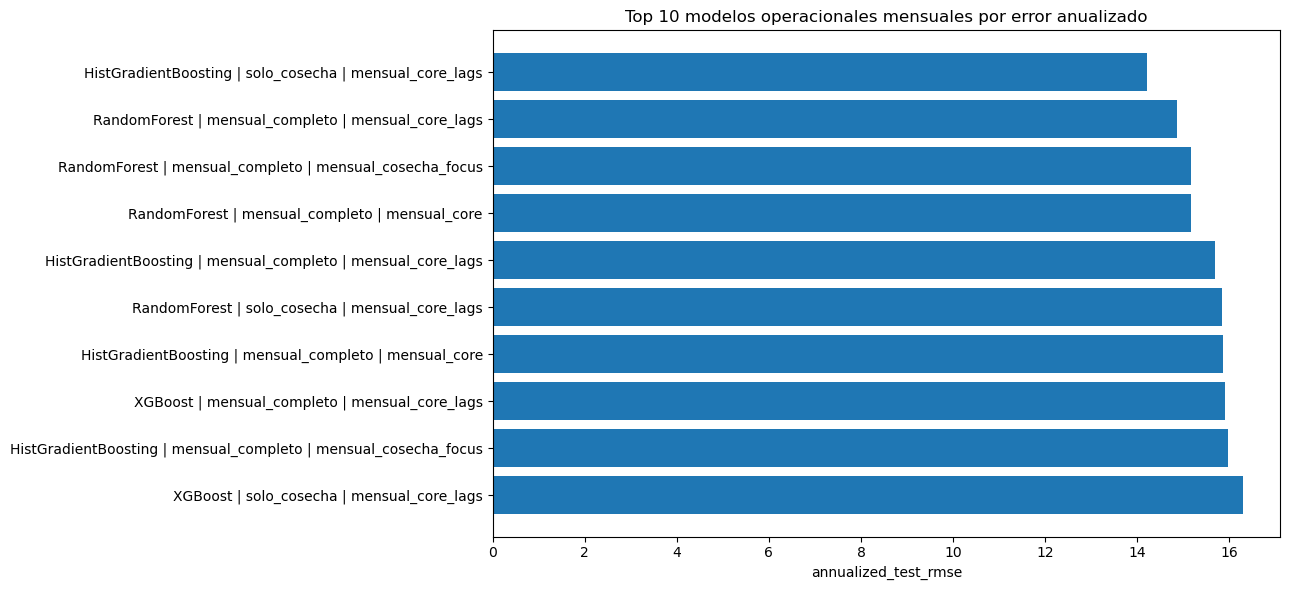

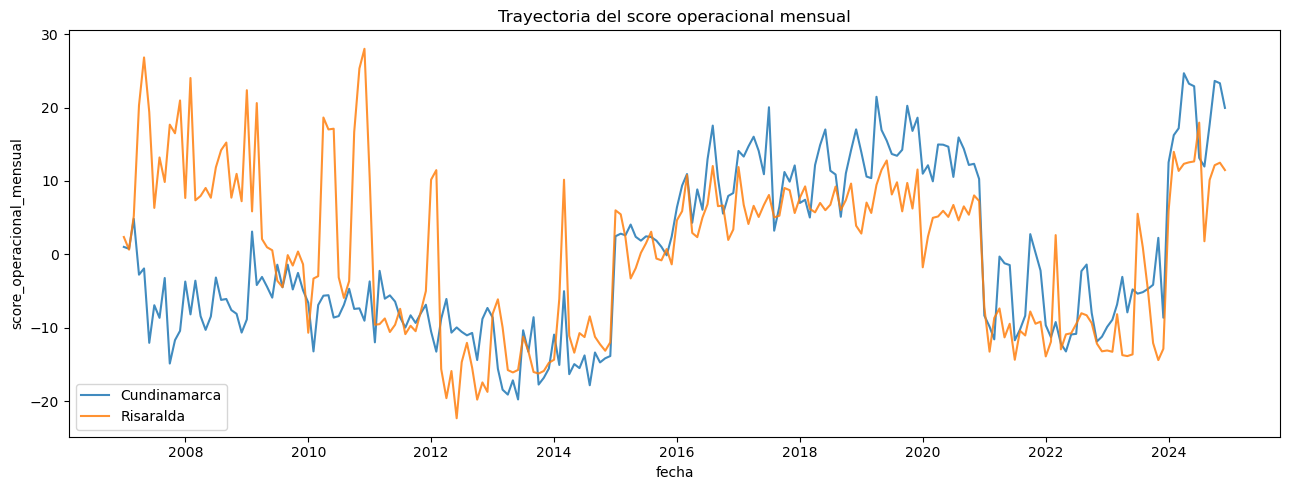

In [33]:
if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    top_plot = test_results_df.head(10).copy()
    labels = top_plot['model_name'] + ' | ' + top_plot['sample_name'] + ' | ' + top_plot['feature_set']
    plt.figure(figsize=(13, 6))
    plt.barh(labels, top_plot['annualized_test_rmse'])
    plt.gca().invert_yaxis()
    plt.xlabel('annualized_test_rmse')
    plt.title('Top 10 modelos operacionales mensuales por error anualizado')
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(score_operacional_mensual) > 0:
    plot_df = score_operacional_mensual.loc[score_operacional_mensual['departamento'].isin(['Cundinamarca', 'Risaralda'])].copy()
    plt.figure(figsize=(13, 5))
    for depto, grp in plot_df.groupby('departamento'):
        plt.plot(grp['fecha'], grp['score_operacional_mensual'], label=depto, alpha=0.85)
    plt.title('Trayectoria del score operacional mensual')
    plt.xlabel('fecha')
    plt.ylabel('score_operacional_mensual')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Exportacion de resultados

Las salidas quedan listas para:

- informe tecnico
- dashboard
- comparacion contra el notebook 10 anual
- insumo del notebook 11

In [34]:
export_status = []

try:
    dependency_report.to_csv(OUTPUT_DIR / 'dependencias_detectadas.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': f'fallo: {exc}'})

try:
    feature_sets_table.to_csv(OUTPUT_DIR / 'feature_sets_utilizados.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': f'fallo: {exc}'})

if len(cv_results_df) > 0:
    try:
        cv_results_df.to_csv(OUTPUT_DIR / 'resumen_cv_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': f'fallo: {exc}'})

if len(test_results_df) > 0:
    try:
        test_results_df.to_csv(OUTPUT_DIR / 'resumen_test_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_models_summary) > 0:
    try:
        top_models_summary.to_csv(OUTPUT_DIR / 'top_modelos_operacionales.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'top_modelos_operacionales.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'top_modelos_operacionales.csv', 'estado': f'fallo: {exc}'})

if len(event_priority_summary) > 0:
    try:
        event_priority_summary.to_csv(OUTPUT_DIR / 'modelos_operacionales_priorizando_eventos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'modelos_operacionales_priorizando_eventos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'modelos_operacionales_priorizando_eventos.csv', 'estado': f'fallo: {exc}'})

if len(monthly_predictions_df) > 0:
    try:
        monthly_predictions_df.to_csv(OUTPUT_DIR / 'predicciones_mensuales_holdout.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_mensuales_holdout.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_mensuales_holdout.csv', 'estado': f'fallo: {exc}'})

if len(annualized_predictions_df) > 0:
    try:
        annualized_predictions_df.to_csv(OUTPUT_DIR / 'predicciones_anualizadas_holdout.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_anualizadas_holdout.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_anualizadas_holdout.csv', 'estado': f'fallo: {exc}'})

if len(score_operacional_mensual) > 0:
    try:
        score_operacional_mensual.to_csv(OUTPUT_DIR / 'score_operacional_mensual.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'score_operacional_mensual.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'score_operacional_mensual.csv', 'estado': f'fallo: {exc}'})

config_payload = {
    'target_operacional': TARGET,
    'event_threshold': EVENT_THRESHOLD,
    'train_end_year': TRAIN_END_YEAR,
    'test_start_year': TEST_START_YEAR,
    'cv_min_train_years': CV_MIN_TRAIN_YEARS,
    'cv_valid_window': CV_VALID_WINDOW,
    'feature_sets': feature_sets,
}
try:
    safe_write_text(OUTPUT_DIR / 'config_experimento.json', json.dumps(config_payload, ensure_ascii=False, indent=2))
    export_status.append({'archivo': 'config_experimento.json', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'config_experimento.json', 'estado': f'fallo: {exc}'})

safe_write_text(OUTPUT_DIR / 'run_log_10_1_operacional_mensual.txt', '\n'.join(run_log))
export_status.append({'archivo': 'run_log_10_1_operacional_mensual.txt', 'estado': 'ok o intento de escritura realizado'})


if len(operational_traceability) > 0:
    try:
        operational_traceability.to_csv(OUTPUT_DIR / 'trazabilidad_operacional_prototipo.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'trazabilidad_operacional_prototipo.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'trazabilidad_operacional_prototipo.csv', 'estado': f'fallo: {exc}'})

if len(operational_candidates) > 0:
    try:
        operational_candidates.to_csv(OUTPUT_DIR / 'candidatos_operacionales_por_objetivo.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'candidatos_operacionales_por_objetivo.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'candidatos_operacionales_por_objetivo.csv', 'estado': f'fallo: {exc}'})

if len(operational_candidate_summary) > 0:
    try:
        operational_candidate_summary.to_csv(OUTPUT_DIR / 'resumen_candidatos_operacionales.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_candidatos_operacionales.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_candidatos_operacionales.csv', 'estado': f'fallo: {exc}'})

if len(prototype_pending_plan) > 0:
    try:
        prototype_pending_plan.to_csv(OUTPUT_DIR / 'plan_pendientes_prototipo_operacional.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'plan_pendientes_prototipo_operacional.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'plan_pendientes_prototipo_operacional.csv', 'estado': f'fallo: {exc}'})

export_status_df = pd.DataFrame(export_status)
display(export_status_df)



,archivo,estado
0,dependencias_detectadas.csv,ok
1,feature_sets_utilizados.csv,ok
2,resumen_cv_modelos.csv,ok
3,resumen_test_modelos.csv,ok
4,top_modelos_operacionales.csv,ok
5,modelos_operacionales_priorizando_eventos.csv,ok
6,predicciones_mensuales_holdout.csv,ok
7,predicciones_anualizadas_holdout.csv,ok
8,score_operacional_mensual.csv,ok
9,config_experimento.json,ok


## Lectura final

El valor de este notebook no es reemplazar el modelado anual, sino traducirlo a una capa mensual util para el artefacto: trigger, score, monitoreo y simulacion.

In [35]:
final_summary = []

if len(test_results_df) > 0:
    best = test_results_df.iloc[0]
    best_event = event_priority_summary.iloc[0] if len(event_priority_summary) > 0 else best
    final_summary.extend([
        {'tema': 'mejor_modelo_operacional_general', 'lectura': f"{best['model_name']} | {best['sample_name']} | {best['feature_set']}"},
        {'tema': 'mejor_rmse_anualizado', 'lectura': f"{best['annualized_test_rmse']:.4f}"},
        {'tema': 'mejor_r2_anualizado', 'lectura': f"{best['annualized_test_r2']:.4f}"},
        {'tema': 'mejor_modelo_eventos', 'lectura': f"{best_event['model_name']} | {best_event['sample_name']} | {best_event['feature_set']}"},
        {'tema': 'recall_eventos_mejor_modelo_eventos', 'lectura': f"{best_event['event_recall']:.4f}"},
        {'tema': 'f1_eventos_mejor_modelo_eventos', 'lectura': f"{best_event['event_f1']:.4f}"},
        {'tema': 'sample_operacional_recomendado', 'lectura': str(best['sample_name'])},
        {'tema': 'necesidad_de_regla_trigger', 'lectura': 'si, queda pendiente convertir el score en regla de activacion operativa'},
    ])
else:
    final_summary.append({'tema': 'estado', 'lectura': 'No se ejecutaron modelos operacionales mensuales en este entorno.'})

display(pd.DataFrame(final_summary))
print('Notebook 10.1 listo.')


,tema,lectura
0,mejor_modelo_operacional_general,HistGradientBoosting | solo_cosecha | mensual_core_lags
1,mejor_rmse_anualizado,14.2154
2,mejor_r2_anualizado,0.0764
3,mejor_modelo_eventos,HuberRegressor | solo_cosecha | mensual_core_lags
4,recall_eventos_mejor_modelo_eventos,0.5000
5,f1_eventos_mejor_modelo_eventos,0.6667
6,sample_operacional_recomendado,solo_cosecha
7,necesidad_de_regla_trigger,"si, queda pendiente convertir el score en regla de activacion operativa"


Notebook 10.1 listo.
